<a href="https://colab.research.google.com/github/Markwema86/-The-DCF-Valuation-Model/blob/main/The_DCF_Valuation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Project 4: DCF Valuation Model
# Purpose: Estimate intrinsic value of a public company

# Pull Historical Financial Data
!pip install yfinance pandas numpy matplotlib -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression

# --- User Input: Choose your company to value ---
TICKER = "AAPL"

company = yf.Ticker(TICKER)
company_name = company.info.get('longName', TICKER)

# Pull financial statements
income = company.financials.T
balance = company.balance_sheet.T
cashflow = company.cashflow.T

# Get current market data
current_price = company.info.get('currentPrice', company.info.get('regularMarketPreviousClose',None))
shares_outstanding = company.info.get('sharesOutstanding', None)
market_cap = company.info.get('marketCap', None)

print(f"🔍 Valuing: {company_name} ({TICKER})")
print(f"Current Price: ${current_price:.2f}" if current_price else "Current Price: N/A")
print(f"Market Cap: ${market_cap:,.0f}" if market_cap else "Market Cap: N/A")
print(f"Shares Outstanding: {shares_outstanding:,.0f}"if shares_outstanding else "Shares: N/A")

🔍 Valuing: Apple Inc. (AAPL)
Current Price: $270.23
Market Cap: $3,971,820,552,192
Shares Outstanding: 14,681,140,000


In [17]:
# Calculate Historical Free Cash Flow to Firm (FCFF)
# important calculation - You cannot value a company without understanding how cash moves

def safe_get(df, possible_names):
  """Extract data safely with multiple possible column names."""
  for name in possible_names:
    if name in df.columns:
      return df[name]
  return pd.Series([np.nan] * len(df), index=df.index)

# --- Extract Required Items ---
# Incoe Statement
ebit = safe_get(income, ['EBIT', 'Operating Income'])
tax_expense = safe_get(income, ['Tax Provision', 'Income Tax Expense'])
revenue = safe_get(income,['Total Revenue', 'Total Revenues'])

# Balance Sheet
total_assets = safe_get(balance, ['Total Assets'])
total_liabilities = safe_get(balance, ['Total Liabilities Net Minority Interest', 'Total Liabilities'])
total_debt = safe_get(balance, ['Total Debt', 'Long Term Debt', 'Long Term Debt And Capital Lease Obligation'])
cash_equiv = safe_get(balance, ['Cash And Cash Equivalents', 'Cash & Equivalents'])

# Cash Flow Ststement
capex = safe_get(cashflow, ['Capital Expenditure', 'Capital Expenditures', 'Purchase Of Property Plant And Equipment'])
#Capex is usually negative; we atke absolute value for FCFF calculation
capex = capex.abs()
depreciation = safe_get(cashflow, ['Depreciation & Amortization', 'Depreciation And Amortization', 'Depreciation'])
change_in_nwc = safe_get(cashflow, ['Change In Working Capital', 'Changes In Working Capital'])

# If changes in NWC not availabale, approximate with Current Assets/Liabilitites change
if change_in_nwc.isna().all():
  current_assets = safe_get(balance, ['Current Assets', 'Total Current Assets'])
  current_liab = safe_get(balance, ['Current Liabilities', 'Total Current Liabilities'])
  nwc = current_assets - current_liab
  change_in_nwc = -nwc.diff() # negative diff = cash outflow

# --- Calculate Effective Tax Rate ---
effective_tax_rate = tax_expense / ebit
effective_tax_rate = effective_tax_rate.clip(0, 0.40) # Cap at 40% for realism

# --- Calculate FCFF ---
# FCFF = EBIT * (1 - Tax Rate) + Depreciation - Capex - Change in NWC
fcff = (ebit * (1 - effective_tax_rate)) + depreciation - capex - change_in_nwc

# Create historical dataframe
historical_data = pd.DataFrame({
    'Revenue': revenue,
    'EBIT': ebit,
    'Tax Rate %': effective_tax_rate * 100,
    'NOPAT' : ebit * (1 - effective_tax_rate),
    'Depreciation': depreciation,
    'Capex': capex,
    'Change in NWC': change_in_nwc,
    'FCFF': fcff
}).sort_index(ascending=True)

print("\n📊 Historical Financials (Moast Recent Years)")
print("=" * 70)
print(historical_data.tail(5).round(2))


📊 Historical Financials (Moast Recent Years)
                 Revenue          EBIT  Tax Rate %         NOPAT  \
2021-09-30           NaN           NaN         NaN           NaN   
2022-09-30  3.943280e+11  1.194370e+11       16.16  1.001370e+11   
2023-09-30  3.832850e+11  1.143010e+11       14.65  9.756000e+10   
2024-09-30  3.910350e+11  1.232160e+11       24.14  9.346700e+10   
2025-09-30  4.161610e+11  1.330500e+11       15.57  1.123310e+11   

            Depreciation         Capex  Change in NWC          FCFF  
2021-09-30           NaN           NaN            NaN           NaN  
2022-09-30  1.110400e+10  1.070800e+10   1.200000e+09  9.933300e+10  
2023-09-30  1.151900e+10  1.095900e+10  -6.577000e+09  1.046970e+11  
2024-09-30  1.144500e+10  9.447000e+09   3.651000e+09  9.181400e+10  
2025-09-30  1.169800e+10  1.271500e+10  -2.500000e+10  1.363140e+11  


In [18]:
from ast import Eq
# Calculate Weighted Average Cost of Capital (WACC) - This is the discount rate. It's the most debated number in finance.
def calcualate_wacc(ticker):
  """
  Calculate WACC using market data and assumptions.
  WACC = (E/V) * Cost of Equity + (D/V) * Cost of Debt * (1 - Tax Rate)
  """
  # --- Cost of Equity (CAPM) ---
  # Risk-Free Rate: 10-Year Treasury (~4.5% as of 2026)
  risk_free_rate = 0.045

  # Market Risk Premium: Historical avverage ~5-6%
  market_risk_premium = 0.055

  # Beta: From Yahoo Finance
  beta = company.info.get('beta', 1.0)
  if beta is None or beta == 0:
    beta = 1.0

  cost_of_equity = risk_free_rate + (beta * market_risk_premium)

  # --- Cost of Debt ---
  # Interest Expense / Total Debt (approximation)
  interest_expense = safe_get(income, ['Interest Expense', 'Interest Income (Expense)']).iloc[0]
  interest_expense = abs(interest_expense) if pd.notna(interest_expense) else 0

  total_debt_val = total_debt.iloc[0] if pd.notna(total_debt.iloc[0]) else 1
  cost_of_debt = interest_expense / total_debt_val if total_debt_val > 0 else 0.05
  cost_of_debt = min(cost_of_debt, 0.15) # Cap at 15%

  # --- Capital Structure Weights ---
  # Market Value of Equity
  equity_value = company.info.get('marketCap', 1e9)

  # Market Value of Debt (using book value as proxy)
  debt_value = total_debt_val if pd.notna(total_debt_val) else 0

  total_value = equity_value + debt_value

  equity_weight = equity_value / total_value if total_value > 0 else 0.8
  debt_weight = debt_value / total_value if total_value > 0 else 0.2

  # --- Marginal Tax Rate ---
  tax_rate = effective_tax_rate.iloc[0] if len(effective_tax_rate) > 0 and pd.notna(effective_tax_rate.iloc[0]) else 0.21

  # ---WACC Calcualtion ---
  wacc = (equity_weight * cost_of_equity) + (debt_weight * cost_of_debt * (1 - tax_rate))

  return {
      'Risk Free Rate': risk_free_rate,
      'Market Risk Premium': market_risk_premium,
      'Beta': beta,
      'Cost of Equity': cost_of_equity,
      'Cost of Debt': cost_of_debt,
      'Equity Weight': equity_weight,
      'Debt Weight': debt_weight,
      'Tax Rate': tax_rate,
      'WACC': wacc
  }

wacc_components = calcualate_wacc(TICKER)
wacc = wacc_components['WACC']

print("\n📈 WACC Components")
print("=" * 50)
for key, value in wacc_components.items():
    if 'Weight' in key or 'Rate' in key or key in ['Beta', 'WACC']:
        print(f"{key:20s}: {value:.4f}" if isinstance(value, float) else f"{key:20s}: {value}")
print(f"\n🎯 Discount Rate (WACC): {wacc*100:.2f}%")


📈 WACC Components
Risk Free Rate      : 0.0450
Beta                : 1.1090
Equity Weight       : 0.9758
Debt Weight         : 0.0242
Tax Rate            : 0.1557
WACC                : 0.1034

🎯 Discount Rate (WACC): 10.34%


In [19]:
#  Forecast Future FCFF
def forecast_fcff(historical_fcff, revenue_growth_asssumption, margin_assumption, years=5):
  """
  Simple forecasting based on revenue growth and margin as sumptions.
  """
  # Get most recent actuals
  last_revenue = revenue.iloc[0]
  last_ebit_margin = (ebit.iloc[0] / revenue.iloc[0]) if revenue.iloc[0] > 0 else 0.15
  last_depreciation_pct = (depreciation.iloc[0] / revenue.iloc[0]) if revenue.iloc[0] > 0 else 0.03
  last_capex_pct = (capex.iloc[0] / revenue.iloc[0]) if revenue.iloc[0] > 0 else 0.04
  last_nwc_change_pct = (change_in_nwc.iloc[0] / revenue.iloc[0]) if revenue.iloc[0] > 0 else 0.01
  last_tax_rate = effective_tax_rate.iloc[0]

  forecasts = []
  current_revenue = last_revenue

  for year in range(1, years + 1):
    # Growth decays towards terminal rate
    growth = revenue_growth_asssumption * (1 - (year-1) * 0.1)
    growth = max(growth, 0.03) # floor at 3%

    current_revenue = current_revenue * (1 + growth)

    projected_ebit = current_revenue * last_ebit_margin
    projected_nopat = projected_ebit * (1 - last_tax_rate)
    projected_dep = current_revenue * last_depreciation_pct
    projected_capex = current_revenue * last_capex_pct
    projected_nwc_change = current_revenue * last_nwc_change_pct

    projected_fcff = projected_nopat + projected_dep - projected_capex - projected_nwc_change
    projected_nwc_change

    forecasts.append({
        'Year': f'Y{year}',
        'Revenue': current_revenue,
        'Growth %': growth * 100,
        'EBIT Margin %': last_ebit_margin * 100,
        'NOPAT': projected_nopat,
        'FCFF': projected_fcff
    })

  return pd.DataFrame(forecasts)

# ---- User Assumptions (Tweak These!) ---
REVENUE_GROWTH = 0.08 # 8% initial growth
TERMINAL_GROWTH = 0.03 # 3% perpetuity growth (CFA standard: ~inflation or GDP)
FORECAST_YEARS = 5 # 5 year forecast

forecast_df = forecast_fcff(fcff, REVENUE_GROWTH, None, FORECAST_YEARS)

print("\n🔮 FCFF Forecast")
print("=" * 80)
print(forecast_df.round(2))


🔮 FCFF Forecast
  Year       Revenue  Growth %  EBIT Margin %         NOPAT          FCFF
0   Y1  4.494539e+11       8.0          31.97  1.213175e+11  1.472191e+11
1   Y2  4.818146e+11       7.2          31.97  1.300523e+11  1.578189e+11
2   Y3  5.126507e+11       6.4          31.97  1.383757e+11  1.679193e+11
3   Y4  5.413591e+11       5.6          31.97  1.461247e+11  1.773228e+11
4   Y5  5.673444e+11       4.8          31.97  1.531387e+11  1.858343e+11


In [20]:
ev_components = calculate_enterprise_value(forecast_df, wacc, TERMINAL_GROWTH)

print("\n💰 Enterprise Value Calculation")
print("=" * 50)
for key, value in ev_components.items():
    if 'Value' in key and 'Undiscounted' not in key:
        print(f"{key:30s}: ${value:.0f}")
    elif '%' in key:
        print(f"{key:30s}: {value:.1f}%")


💰 Enterprise Value Calculation
PV of Terminal Value          : $1593665970259
Enterprise Value              : $2214919854435
Terminal Value % of EV        : $72


In [21]:
# Bridge to Equity Value and Fair Value Per Share
# --- Calcualate Net Debt ---
latest_debt = total_debt.iloc[0] if len(total_debt) > 0 and pd.notna(total_debt.iloc[0]) else 0
latest_cash = cash_equiv.iloc[0] if len(cash_equiv) > 0 and pd.notna(cash_equiv.iloc[0]) else 0
net_debt = latest_debt - latest_cash

enterprise_value = ev_components['Enterprise Value']
equity_value = enterprise_value - net_debt

fair_value_per_share = equity_value / shares_outstanding if shares_outstanding else None

# --- Comparison to Market ---
upside_pct = ((fair_value_per_share / current_price) - 1) * 100 if fair_value_per_share and current_price else None

print("\n📊 DCF Valuation Summary")
print("=" * 60)
print(f"{'Enterprise Value':25s}: ${enterprise_value:>15,.0f}")
print(f"{'Less: Net Debt':25s}: ${net_debt:>15,.0f}  (Debt: ${latest_debt:,.0f} - Cash: ${latest_cash:,.0f})")
print(f"{'=' * 60}")
print(f"{'Equity Value':25s}: ${equity_value:>15,.0f}")
print(f"{'Shares Outstanding':25s}: {shares_outstanding:>15,.0f}")
print(f"{'=' * 60}")
print(f"{'Fair Value Per Share':25s}: ${fair_value_per_share:>15.2f}")
print(f"{'Current Market Price':25s}: ${current_price:>15.2f}")
print(f"{'=' * 60}")
print(f"{'Upside / (Downside)':25s}: {upside_pct:>15.1f}%")

if upside_pct:
    if upside_pct > 15:
        recommendation = "🟢 STRONG BUY"
    elif upside_pct > 0:
        recommendation = "🟡 BUY"
    elif upside_pct > -15:
        recommendation = "🟠 HOLD"
    else:
        recommendation = "🔴 SELL"

    print(f"{'Recommendation':25s}: {recommendation}")


📊 DCF Valuation Summary
Enterprise Value         : $2,214,919,854,435
Less: Net Debt           : $ 62,723,000,000  (Debt: $98,657,000,000 - Cash: $35,934,000,000)
Equity Value             : $2,152,196,854,435
Shares Outstanding       :  14,681,140,000
Fair Value Per Share     : $         146.60
Current Market Price     : $         270.23
Upside / (Downside)      :           -45.8%
Recommendation           : 🔴 SELL


In [22]:
# Sensitivity Analysis (The CFA Level II Requirement)
# No DCF is complete without a sensitivity table. This shows how the fair value changes with different WACC and growth assumptions.
def sensitivity_analysis(base_wacc, base_growth, forecast_df, terminal_growth, net_debt, shares):
    """
    Create a sensitivity matrix for WACC vs Terminal Growth.
    """
    # Check for NaN inputs that would cause np.arange to fail
    if np.isnan(base_wacc) or np.isnan(terminal_growth):
        print("Warning: Cannot perform sensitivity analysis because base WACC or terminal growth rate is NaN.")
        return pd.DataFrame() # Return an empty DataFrame

    wacc_range = np.arange(base_wacc - 0.02, base_wacc + 0.025, 0.005)
    growth_range = np.arange(terminal_growth - 0.015, terminal_growth + 0.02, 0.005)

    # Clip to reasonable ranges
    wacc_range = wacc_range[(wacc_range > 0.03) & (wacc_range < 0.15)]
    growth_range = growth_range[(growth_range > 0.01) & (growth_range < 0.06)]

    results = []
    for g in growth_range:
        row = []
        for w in wacc_range:
            if w <= g:
                row.append(np.nan)  # Invalid: WACC must exceed growth
            else:
                ev_comp = calculate_enterprise_value(forecast_df, w, g)
                eq_value = ev_comp['Enterprise Value'] - net_debt
                fair_value = eq_value / shares
                row.append(fair_value)
        results.append(row)

    sensitivity_df = pd.DataFrame(results,
                                  index=[f"{g*100:.1f}%" for g in growth_range],
                                  columns=[f"{w*100:.1f}%" for w in wacc_range])

    return sensitivity_df

if shares_outstanding:
    sens_df = sensitivity_analysis(wacc, REVENUE_GROWTH, forecast_df,
                                   TERMINAL_GROWTH, net_debt, shares_outstanding)

    if not sens_df.empty: # Only print if sensitivity_analysis returned a non-empty DataFrame
        print("\n📉 Sensitivity Analysis: Fair Value Per Share")
        print("=" * 60)
        print("Rows: Terminal Growth Rate | Columns: WACC")
        print("-" * 60)
        print(sens_df.round(2))


📉 Sensitivity Analysis: Fair Value Per Share
Rows: Terminal Growth Rate | Columns: WACC
------------------------------------------------------------
        8.3%    8.8%    9.3%    9.8%   10.3%   10.8%   11.3%   11.8%   12.3%  \
1.5%  166.16  154.33  144.00  134.92  126.87  119.68  113.23  107.40  102.11   
2.0%  176.75  163.30  151.69  141.57  132.66  124.76  117.71  111.37  105.66   
2.5%  189.14  173.69  160.50  149.12  139.18  130.44  122.69  115.77  109.56   
3.0%  203.86  185.86  170.71  157.77  146.60  136.85  128.27  120.67  113.88   
3.5%  221.61  200.31  182.66  167.79  155.09  144.13  134.57  126.15  118.69   
4.0%  243.45  217.74  196.84  179.52  164.93  152.48  141.72  132.33  124.08   
4.5%  270.98  239.18  213.95  193.45  176.45  162.14  149.91  139.36  130.15   
5.0%  306.74  266.21  235.01  210.25  190.13  173.45  159.40  147.41  137.05   

       12.8%  
1.5%   97.29  
2.0%  100.47  
2.5%  103.95  
3.0%  107.78  
3.5%  112.03  
4.0%  116.75  
4.5%  122.04  
5.0%  128

In [23]:
# Calculate Terminal Value and Enterprise Value
def calculate_terminal_value(final_year_fcff, wacc, terminal_growth):
  """
  Terminal Value using Gordon Growth Model
  TV = (FCFF_n * (1 + g)) / (WACC - g)
  """
  return (final_year_fcff * (1 + terminal_growth)) / (wacc - terminal_growth)

def calculate_enterprise_value(forecast_df, wacc, terminal_growth):
  """
  Discount forecast FCFF and terminal value to present
  """
  fcff_forecast = forecast_df['FCFF'].values
  years = len(fcff_forecast)

  # PV of explicit forecast period
  pv_fcff = 0
  for t, fcff_val in enumerate(fcff_forecast, 1):
    pv_fcff += fcff_val / ((1 + wacc) ** t)

  # terminal value
  terminal_value = calculate_terminal_value(fcff_forecast[-1], wacc, terminal_growth)
  pv_terminal = terminal_value / ((1 + wacc) ** years)

  enterprise_value = pv_fcff + pv_terminal

  return {
      'PV of FCFF Forecast': pv_fcff,
      'Terminal Value (Undiscounted)': terminal_value,
      'PV of Terminal Value': pv_terminal,
      'Enterprise Value': enterprise_value,
      'Terminal Value % of EV': (pv_terminal / enterprise_value) * 100
  }

ev_components = calculate_enterprise_value(forecast_df, wacc, TERMINAL_GROWTH)

print("\n💰 Enterprise Value Calculation")
print("=" * 50)
for key, value in ev_components.items():
    if 'Value' in key and 'Undiscounted' not in key:
        print(f"{key:30s}: ${value:.0f}")
    elif '%' in key:
        print(f"{key:30s}: {value:.1f}%")


💰 Enterprise Value Calculation
PV of Terminal Value          : $1593665970259
Enterprise Value              : $2214919854435
Terminal Value % of EV        : $72


In [24]:
# Bridge to Equity Value and Fair Value Per Share
# --- Calcualate Net Debt ---
latest_debt = total_debt.iloc[0] if len(total_debt) > 0 and pd.notna(total_debt.iloc[0]) else 0
latest_cash = cash_equiv.iloc[0] if len(cash_equiv) > 0 and pd.notna(cash_equiv.iloc[0]) else 0
net_debt = latest_debt - latest_cash

enterprise_value = ev_components['Enterprise Value']
equity_value = enterprise_value - net_debt

fair_value_per_share = equity_value / shares_outstanding if shares_outstanding else None

# --- Comparison to Market ---
upside_pct = ((fair_value_per_share / current_price) - 1) * 100 if fair_value_per_share and current_price else None

print("\n📊 DCF Valuation Summary")
print("=" * 60)
print(f"{'Enterprise Value':25s}: ${enterprise_value:>15,.0f}")
print(f"{'Less: Net Debt':25s}: ${net_debt:>15,.0f}  (Debt: ${latest_debt:,.0f} - Cash: ${latest_cash:,.0f})")
print(f"{'=' * 60}")
print(f"{'Equity Value':25s}: ${equity_value:>15,.0f}")
print(f"{'Shares Outstanding':25s}: {shares_outstanding:>15,.0f}")
print(f"{'=' * 60}")
print(f"{'Fair Value Per Share':25s}: ${fair_value_per_share:>15.2f}")
print(f"{'Current Market Price':25s}: ${current_price:>15.2f}")
print(f"{'=' * 60}")
print(f"{'Upside / (Downside)':25s}: {upside_pct:>15.1f}%")

if upside_pct:
    if upside_pct > 15:
        recommendation = "🟢 STRONG BUY"
    elif upside_pct > 0:
        recommendation = "🟡 BUY"
    elif upside_pct > -15:
        recommendation = "🟠 HOLD"
    else:
        recommendation = "🔴 SELL"

    print(f"{'Recommendation':25s}: {recommendation}")


📊 DCF Valuation Summary
Enterprise Value         : $2,214,919,854,435
Less: Net Debt           : $ 62,723,000,000  (Debt: $98,657,000,000 - Cash: $35,934,000,000)
Equity Value             : $2,152,196,854,435
Shares Outstanding       :  14,681,140,000
Fair Value Per Share     : $         146.60
Current Market Price     : $         270.23
Upside / (Downside)      :           -45.8%
Recommendation           : 🔴 SELL


In [25]:
# Sensitivity Analysis (The CFA Level II Requirement)
# No DCF is complete without a sensitivity table. This shows how the fair value changes with different WACC and growth assumptions.
def sensitivity_analysis(base_wacc, base_growth, forecast_df, terminal_growth, net_debt, shares):
    """
    Create a sensitivity matrix for WACC vs Terminal Growth.
    """
    # Check for NaN inputs that would cause np.arange to fail
    if np.isnan(base_wacc) or np.isnan(terminal_growth):
        print("Warning: Cannot perform sensitivity analysis because base WACC or terminal growth rate is NaN.")
        return pd.DataFrame() # Return an empty DataFrame

    wacc_range = np.arange(base_wacc - 0.02, base_wacc + 0.025, 0.005)
    growth_range = np.arange(terminal_growth - 0.015, terminal_growth + 0.02, 0.005)

    # Clip to reasonable ranges
    wacc_range = wacc_range[(wacc_range > 0.03) & (wacc_range < 0.15)]
    growth_range = growth_range[(growth_range > 0.01) & (growth_range < 0.06)]

    results = []
    for g in growth_range:
        row = []
        for w in wacc_range:
            if w <= g:
                row.append(np.nan)  # Invalid: WACC must exceed growth
            else:
                ev_comp = calculate_enterprise_value(forecast_df, w, g)
                eq_value = ev_comp['Enterprise Value'] - net_debt
                fair_value = eq_value / shares
                row.append(fair_value)
        results.append(row)

    sensitivity_df = pd.DataFrame(results,
                                  index=[f"{g*100:.1f}%" for g in growth_range],
                                  columns=[f"{w*100:.1f}%" for w in wacc_range])

    return sensitivity_df

if shares_outstanding:
    sens_df = sensitivity_analysis(wacc, REVENUE_GROWTH, forecast_df,
                                   TERMINAL_GROWTH, net_debt, shares_outstanding)

    if not sens_df.empty: # Only print if sensitivity_analysis returned a non-empty DataFrame
        print("\n📉 Sensitivity Analysis: Fair Value Per Share")
        print("=" * 60)
        print("Rows: Terminal Growth Rate | Columns: WACC")
        print("-" * 60)
        print(sens_df.round(2))


📉 Sensitivity Analysis: Fair Value Per Share
Rows: Terminal Growth Rate | Columns: WACC
------------------------------------------------------------
        8.3%    8.8%    9.3%    9.8%   10.3%   10.8%   11.3%   11.8%   12.3%  \
1.5%  166.16  154.33  144.00  134.92  126.87  119.68  113.23  107.40  102.11   
2.0%  176.75  163.30  151.69  141.57  132.66  124.76  117.71  111.37  105.66   
2.5%  189.14  173.69  160.50  149.12  139.18  130.44  122.69  115.77  109.56   
3.0%  203.86  185.86  170.71  157.77  146.60  136.85  128.27  120.67  113.88   
3.5%  221.61  200.31  182.66  167.79  155.09  144.13  134.57  126.15  118.69   
4.0%  243.45  217.74  196.84  179.52  164.93  152.48  141.72  132.33  124.08   
4.5%  270.98  239.18  213.95  193.45  176.45  162.14  149.91  139.36  130.15   
5.0%  306.74  266.21  235.01  210.25  190.13  173.45  159.40  147.41  137.05   

       12.8%  
1.5%   97.29  
2.0%  100.47  
2.5%  103.95  
3.0%  107.78  
3.5%  112.03  
4.0%  116.75  
4.5%  122.04  
5.0%  128

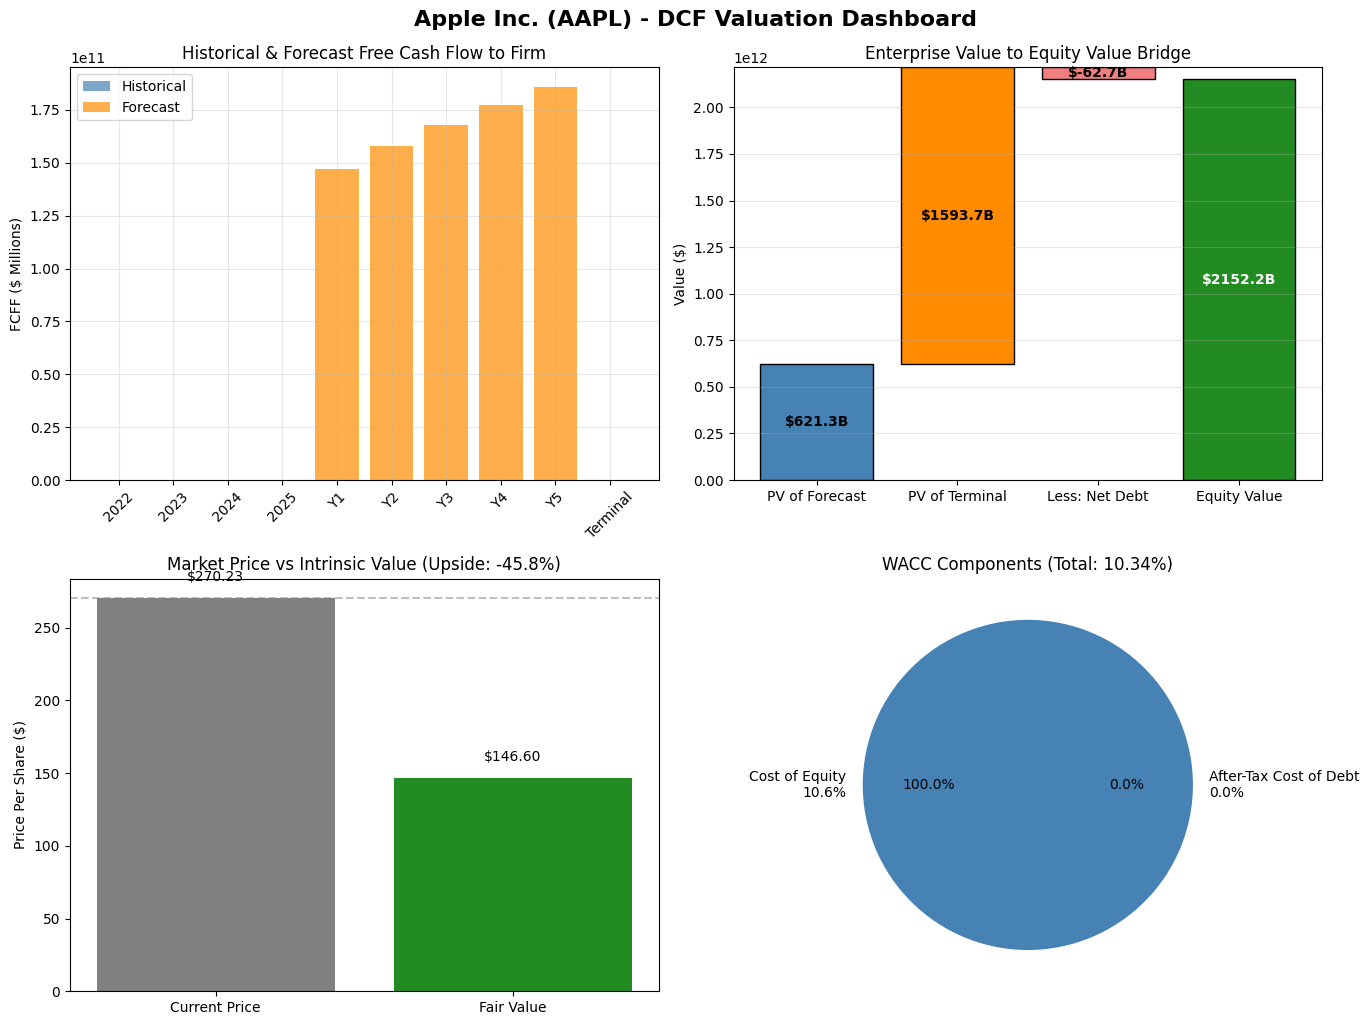

In [27]:
#Visualize the Valuation
def plot_valuation_summary(historical_data, forecast_df, fair_value, current_price):
    """Create a professional valuation dashboard."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Historical vs Forecast FCFF
    ax1 = axes[0, 0]
    hist_years = historical_data.index.year[-4:]
    hist_fcff = historical_data['FCFF'].values[-4:]

    fore_years = ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Terminal']
    fore_fcff = list(forecast_df['FCFF'].values) + [ev_components['Terminal Value (Undiscounted)'] / 1000000]

    ax1.bar(range(len(hist_years)), hist_fcff / 1e6, color='steelblue', alpha=0.7, label='Historical')
    ax1.bar(range(len(hist_years), len(hist_years) + len(fore_fcff)),
            fore_fcff, color='darkorange', alpha=0.7, label='Forecast')
    ax1.set_xticks(range(len(hist_years) + len(fore_fcff)))
    ax1.set_xticklabels(list(hist_years) + fore_years, rotation=45)
    ax1.set_ylabel('FCFF ($ Millions)')
    ax1.set_title('Historical & Forecast Free Cash Flow to Firm')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Valuation Waterfall
    ax2 = axes[0, 1]
    waterfall_values = [
        ev_components['PV of FCFF Forecast'],
        ev_components['PV of Terminal Value'],
        -net_debt
    ]
    waterfall_labels = ['PV of Forecast', 'PV of Terminal', 'Less: Net Debt']
    colors = ['steelblue', 'darkorange', 'lightcoral' if net_debt > 0 else 'lightgreen']

    cumulative = 0
    for i, (val, label, color) in enumerate(zip(waterfall_values, waterfall_labels, colors)):
        ax2.bar(i, val, bottom=cumulative if i > 0 else 0, color=color, edgecolor='black')
        ax2.text(i, cumulative + val/2, f'${val/1e9:.1f}B', ha='center', va='center', fontweight='bold')
        cumulative += val

    ax2.bar(len(waterfall_values), equity_value, color='forestgreen', edgecolor='black')
    ax2.text(len(waterfall_values), equity_value/2, f'${equity_value/1e9:.1f}B',
             ha='center', va='center', fontweight='bold', color='white')

    ax2.set_xticks(range(len(waterfall_values) + 1))
    ax2.set_xticklabels(waterfall_labels + ['Equity Value'])
    ax2.set_ylabel('Value ($)')
    ax2.set_title('Enterprise Value to Equity Value Bridge')
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Price Comparison
    ax3 = axes[1, 0]
    if fair_value and current_price:
        bars = ax3.bar(['Current Price', 'Fair Value'], [current_price, fair_value],
                       color=['gray', 'forestgreen'])
        ax3.axhline(y=current_price, color='gray', linestyle='--', alpha=0.5)
        ax3.set_ylabel('Price Per Share ($)')
        ax3.set_title(f'Market Price vs Intrinsic Value (Upside: {upside_pct:.1f}%)')
        ax3.bar_label(bars, fmt='$%.2f', padding=10)

    # Plot 4: WACC Components Pie Chart
    ax4 = axes[1, 1]
    components = [
        wacc_components['Equity Weight'] * wacc_components['Cost of Equity'],
        wacc_components['Debt Weight'] * wacc_components['Cost of Debt'] * (1 - wacc_components['Tax Rate'])
    ]
    labels = [f"Cost of Equity\n{wacc_components['Cost of Equity']*100:.1f}%",
              f"After-Tax Cost of Debt\n{wacc_components['Cost of Debt']*100*(1-wacc_components['Tax Rate']):.1f}%"]
    ax4.pie(components, labels=labels, autopct='%1.1f%%', colors=['steelblue', 'lightcoral'])
    ax4.set_title(f'WACC Components (Total: {wacc*100:.2f}%)')

    plt.tight_layout()
    plt.suptitle(f'{company_name} ({TICKER}) - DCF Valuation Dashboard',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Generate the dashboard
if shares_outstanding and current_price:
    plot_valuation_summary(historical_data, forecast_df, fair_value_per_share, current_price)